# Deep learning segmentation of spectrogram in a supervised setting

# load Dataset

In [1]:
process = True

In [2]:
import os
import numpy as np
import json
from pathlib import Path

def load_mask_with_spectrograms(path: str | Path) -> dict:
    path = Path(path)
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


if process == True:

    # List all elements (files and folders)
    elements = os.listdir('data_mask_spectro/')

    X_eeg =  []
    X_spec = []
    Y = []

    for elem in elements:
        if '.json' in elem:
            # load masks and spectrogram
            data = load_mask_with_spectrograms('data_mask_spectro/' + elem)
            # load recording (use try except since can be from 2 different folders)
            try:
                y = np.load('anesthesia_database/' + data['recording'])
            except:
                y = np.load('anesthesia_database_Trousseau/' + data['recording'])
            # load window key names
            list_windows_keys = list(data['windows'].keys())
            # iterate over all windows
            for i in range(len(data['windows'])):
                current_window = data['windows'][list_windows_keys[i]]
                start_s = float(current_window["window_start_s"])
                end_s = float(current_window["window_end_s"])
                fs = int(current_window["fs_hz"])

                start_i = int(round(start_s * fs))
                end_i = int(round(end_s * fs))

                signal = y[start_i : end_i]
                t_signal = np.arange(len(signal)) / fs

                mask = current_window['mask']

                t_spec = current_window['t_spec']
                f_spec = current_window['f_spec']
                spec = np.array(current_window['spectrogram'])

                X_eeg.append(signal)
                X_spec.append(spec)
                Y.append(mask)


    #--- convert to np arrays
    X_eeg = np.array(X_eeg)
    X_spec = np.array(X_spec)
    Y = np.array(Y)

    np.save('X_Y_dataset/X_eeg', X_eeg)
    np.save('X_Y_dataset/X_spec', X_spec)
    np.save('X_Y_dataset/Y', Y)

else:
    X_eeg =  np.load('X_Y_dataset/X_eeg.npy')
    X_spec =  np.load('X_Y_dataset/X_spec.npy')
    Y = np.load('X_Y_dataset/Y.npy')

# Utilities

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm.auto import tqdm

# -------------------------------------------------
# 1) Train / Val / Test split (classic, no stratify)
# -------------------------------------------------
def split_train_val_test(X, y, test_size=0.2, val_size=0.2, random_state=42):
    """
    val_size is the fraction of the *remaining* data after removing test.
    Example: test_size=0.2, val_size=0.2 -> train=64%, val=16%, test=20%.
    """
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=None
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_size,
        random_state=random_state,
        stratify=None
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

# ----------------------------
# Dataset: numpy -> torch
# X: (N, 45, 297) float32
# y: (N, 297) int64 in [0..9]
# ----------------------------
class SpectrogramSegDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        assert X.ndim == 3 and X.shape[1] == 45 and X.shape[2] == 297
        assert y.ndim == 2 and y.shape[1] == 297
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])         # (45, 297)
        y = torch.from_numpy(self.y[idx])         # (297,)
        return x, y


# ----------------------------
# Dice metric (macro Dice)
# for multiclass segmentation over time axis
# pred: (B, T) int64
# target: (B, T) int64
# ----------------------------
@torch.no_grad()
def dice_score_multiclass(pred: torch.Tensor, target: torch.Tensor, num_classes: int, eps: float = 1e-6):
    # pred/target: (B, T)
    B, T = pred.shape
    pred_oh = F.one_hot(pred, num_classes=num_classes).float()       # (B, T, C)
    tgt_oh  = F.one_hot(target, num_classes=num_classes).float()     # (B, T, C)

    # Sum over batch and time
    pred_sum = pred_oh.sum(dim=(0, 1))     # (C,)
    tgt_sum  = tgt_oh.sum(dim=(0, 1))      # (C,)
    inter    = (pred_oh * tgt_oh).sum(dim=(0, 1))  # (C,)

    dice_c = (2.0 * inter + eps) / (pred_sum + tgt_sum + eps)  # (C,)
    macro = dice_c.mean().item()
    return macro, dice_c.cpu().numpy()


# ----------------------------
# Differentiable Dice loss
# logits: (B, T, C)
# target: (B, T)
# ----------------------------
def dice_loss_from_logits(logits: torch.Tensor, target: torch.Tensor, num_classes: int, eps: float = 1e-6):
    probs = torch.softmax(logits, dim=-1)  # (B, T, C)
    tgt_oh = F.one_hot(target, num_classes=num_classes).float()  # (B, T, C)

    # sum over B,T
    inter = (probs * tgt_oh).sum(dim=(0, 1))       # (C,)
    p_sum = probs.sum(dim=(0, 1))                  # (C,)
    t_sum = tgt_oh.sum(dim=(0, 1))                 # (C,)

    dice = (2.0 * inter + eps) / (p_sum + t_sum + eps)  # (C,)
    return 1.0 - dice.mean()  # scalar


class CEDiceLoss(nn.Module):
    def __init__(self, num_classes: int, dice_weight: float = 0.5, class_weights: torch.Tensor | None = None):
        super().__init__()
        self.num_classes = num_classes
        self.dice_weight = dice_weight
        self.ce = nn.CrossEntropyLoss(weight=class_weights)

    def forward(self, logits: torch.Tensor, target: torch.Tensor):
        # logits (B,T,C) -> CE wants (B,C,T)
        ce = self.ce(logits.permute(0, 2, 1), target)
        dl = dice_loss_from_logits(logits, target, self.num_classes)
        return (1.0 - self.dice_weight) * ce + self.dice_weight * dl


# ----------------------------
# Simple train/eval loops
# ----------------------------

# ----------------------------
# Class weights (more stable for heavy imbalance)
# weights_k = 1 / log(c + freq_k)
# where freq_k = count_k / total. (c slightly > 1)
# ----------------------------
def compute_log_inv_class_weights(y_train: np.ndarray, num_classes: int, c: float = 1.02, eps: float = 1e-12) -> np.ndarray:
    flat = y_train.reshape(-1)
    counts = np.bincount(flat, minlength=num_classes).astype(np.float64)
    freq = counts / max(counts.sum(), 1.0)
    weights = 1.0 / (np.log(c + freq) + eps)
    # normalize mean weight over present classes to 1
    present = counts > 0
    if present.any():
        weights = weights / weights[present].mean()
    # missing classes -> weight 0 (won't matter for CE)
    weights[~present] = 0.0
    return weights.astype(np.float32), counts.astype(np.int64)

# ----------------------------
# Multiclass Focal Loss (drop-in replacement for CrossEntropyLoss)
# - helps with imbalance by down-weighting easy examples.
# ----------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, class_weights: torch.Tensor | None = None, reduction: str = "mean"):
        super().__init__()
        self.gamma = gamma
        self.class_weights = class_weights
        if reduction not in ("mean", "sum", "none"):
            raise ValueError("reduction must be 'mean', 'sum', or 'none'")
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # logits: (B,T,C), target: (B,T)
        # compute per-position CE (no reduction)
        ce = F.cross_entropy(
            logits.permute(0, 2, 1),  # (B,C,T)
            target,
            weight=self.class_weights,
            reduction="none",
        )  # (B,T)

        # pt = exp(-ce) is prob assigned to true class
        pt = torch.exp(-ce)  # (B,T)
        focal = (1.0 - pt).pow(self.gamma) * ce  # (B,T)

        if self.reduction == "mean":
            return focal.mean()
        if self.reduction == "sum":
            return focal.sum()
        return focal

# ----------------------------
# Combined losses
# ----------------------------
class FocalDiceLoss(nn.Module):
    def __init__(self, num_classes: int, dice_weight: float = 0.3, gamma: float = 2.0, class_weights: torch.Tensor | None = None):
        super().__init__()
        self.num_classes = num_classes
        self.dice_weight = dice_weight
        self.focal = FocalLoss(gamma=gamma, class_weights=class_weights, reduction="mean")

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        fl = self.focal(logits, target)
        dl = dice_loss_from_logits(logits, target, self.num_classes)
        return (1.0 - self.dice_weight) * fl + self.dice_weight * dl

class HierarchicalBgThenClassLoss(nn.Module):
    '''
    Two-stage (in one model) loss:
      1) binary: background (class 0) vs non-background (classes 1..C-1)
      2) multiclass among non-background only (masked)

    This is useful when class 0 dominates heavily.
    You can use it with ANY model that outputs logits (B,T,C).
    '''
    def __init__(self, num_classes: int, dice_weight: float = 0.3, gamma: float = 2.0,
                 class_weights: torch.Tensor | None = None, bg_weight: float = 1.0):
        super().__init__()
        self.num_classes = num_classes
        self.dice_weight = dice_weight
        self.bg_weight = bg_weight
        self.focal = FocalLoss(gamma=gamma, class_weights=class_weights, reduction="mean")

        # binary focal for bg vs non-bg (no per-class weights here; bg_weight can compensate)
        self.bin_focal = FocalLoss(gamma=gamma, class_weights=None, reduction="mean")

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # logits: (B,T,C), target: (B,T)
        B, T, C = logits.shape
        assert C == self.num_classes

        # (1) binary head built from multiclass logits:
        # bg logit = logits[...,0], non-bg logit = logsumexp(logits[...,1:])
        bg_logit = logits[..., 0:1]  # (B,T,1)
        nonbg_logit = torch.logsumexp(logits[..., 1:], dim=-1, keepdim=True)  # (B,T,1)
        bin_logits = torch.cat([bg_logit, nonbg_logit], dim=-1)  # (B,T,2)

        bin_target = (target != 0).long()  # 1 = non-bg, 0 = bg
        bin_loss = self.bin_focal(bin_logits, bin_target) * self.bg_weight

        # (2) multiclass among non-bg only (mask positions where target != 0)
        mask = (target != 0)  # (B,T)
        if mask.any():
            logits_nb = logits[mask]  # (N_nonbg, C)
            target_nb = target[mask]  # (N_nonbg,)
            # focal over original classes (still includes class 0, but target_nb != 0 so OK)
            # add dice computed on full logits for stability
            multi_loss = self.focal(logits, target)
        else:
            multi_loss = torch.tensor(0.0, device=logits.device)

        dl = dice_loss_from_logits(logits, target, self.num_classes)

        # total: encourage correct bg/nonbg + within-class separation + overlap quality
        return 0.5 * bin_loss + 0.5 * ((1.0 - self.dice_weight) * multi_loss + self.dice_weight * dl)

# ----------------------------
# Global Dice helpers (proper evaluation)
# ----------------------------
@torch.no_grad()
def collect_preds_targets_flat(model, loader, device):
    model.eval()
    y_true_all, y_pred_all = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        preds = logits.argmax(dim=-1)
        y_true_all.append(y.detach().cpu())
        y_pred_all.append(preds.detach().cpu())
    y_true = torch.cat(y_true_all, dim=0).reshape(-1)
    y_pred = torch.cat(y_pred_all, dim=0).reshape(-1)
    return y_true, y_pred

def global_macro_dice_from_flat(y_true_flat: torch.Tensor, y_pred_flat: torch.Tensor, num_classes: int, eps: float = 1e-6):
    dice_per_class = torch.zeros(num_classes, dtype=torch.float64)
    for k in range(num_classes):
        true_k = (y_true_flat == k)
        pred_k = (y_pred_flat == k)
        tp = (true_k & pred_k).sum().item()
        fp = ((~true_k) & pred_k).sum().item()
        fn = (true_k & (~pred_k)).sum().item()
        dice_per_class[k] = (2.0 * tp + eps) / (2.0 * tp + fp + fn + eps)
    return float(dice_per_class.mean().item()), dice_per_class.cpu().numpy()

@torch.no_grad()
def eval_epoch_global(model, loader, loss_fn, device, num_classes: int):
    model.eval()
    total_loss = 0.0
    n_seen = 0

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    start = time.perf_counter()

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        bs = x.size(0)
        total_loss += loss.item() * bs
        n_seen += bs

    y_true, y_pred = collect_preds_targets_flat(model, loader, device)
    global_dice, dice_per_class = global_macro_dice_from_flat(y_true, y_pred, num_classes=num_classes)

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    avg_loss = total_loss / max(n_seen, 1)
    return avg_loss, global_dice, dice_per_class, elapsed



def run_one_epoch(model, loader, optimizer, loss_fn, device, num_classes: int, train: bool, desc: str = ""):
    model.train(train)
    total_loss = 0.0
    all_macro_dice = []
    n_seen = 0

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    start = time.perf_counter()

    pbar = tqdm(loader, desc=desc, leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        bs = x.size(0)
        n_seen += bs

        with torch.set_grad_enabled(train):
            logits = model(x)  # (B, T, C)
            loss = loss_fn(logits, y)

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * bs

        pred = logits.argmax(dim=-1)  # (B, T)
        macro_dice, _ = dice_score_multiclass(pred, y, num_classes=num_classes)
        all_macro_dice.append(macro_dice)

        # running stats for display
        run_loss = total_loss / n_seen
        run_dice = float(np.mean(all_macro_dice))
        pbar.set_postfix(loss=f"{run_loss:.4f}", dice=f"{run_dice:.4f}")

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    avg_loss = total_loss / len(loader.dataset)
    avg_macro_dice = float(np.mean(all_macro_dice)) if all_macro_dice else float("nan")
    return avg_loss, avg_macro_dice, elapsed



def compute_confusion_matrix(model, loader, device, num_classes):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            preds = logits.argmax(dim=-1)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds).reshape(-1)
    all_targets = np.concatenate(all_targets).reshape(-1)

    cm = confusion_matrix(
        all_targets,
        all_preds,
        labels=list(range(num_classes))
    )

    return cm


def plot_confusion_matrix(cm, class_names, normalize=True):
    cm_plot = cm.astype(np.float64)

    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm_plot, row_sums, where=row_sums != 0)

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_plot, interpolation="nearest")
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    # Annotate cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            value = cm_plot[i, j]
            text = f"{value:.2f}" if normalize else f"{int(cm[i, j])}"
            plt.text(j, i, text, ha="center", va="center")

    plt.tight_layout()
    plt.show()



# ----------------------------
# Global (dataset-level) Dice helpers
# ----------------------------
@torch.no_grad()
def collect_preds_targets(model, loader, device):
    """Collect flattened predictions/targets over a loader."""
    model.eval()
    y_true_all = []
    y_pred_all = []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)   # (B, T)
        logits = model(x)                      # (B, T, C)
        preds = logits.argmax(dim=-1)          # (B, T)
        y_true_all.append(y.detach().cpu())
        y_pred_all.append(preds.detach().cpu())
    y_true = torch.cat(y_true_all, dim=0).reshape(-1)  # (N_frames,)
    y_pred = torch.cat(y_pred_all, dim=0).reshape(-1)  # (N_frames,)
    return y_true, y_pred


def global_macro_dice_from_flat(y_true_flat: torch.Tensor, y_pred_flat: torch.Tensor, num_classes: int, eps: float = 1e-6):
    """Compute macro Dice from flattened vectors (global TP/FP/FN per class)."""
    dice_per_class = torch.zeros(num_classes, dtype=torch.float64)
    for k in range(num_classes):
        true_k = (y_true_flat == k)
        pred_k = (y_pred_flat == k)
        tp = (true_k & pred_k).sum().item()
        fp = ((~true_k) & pred_k).sum().item()
        fn = (true_k & (~pred_k)).sum().item()
        dice_per_class[k] = (2.0 * tp + eps) / (2.0 * tp + fp + fn + eps)
    return float(dice_per_class.mean().item()), dice_per_class.cpu().numpy()


@torch.no_grad()
def eval_epoch_global(model, loader, loss_fn, device, num_classes: int, desc: str = ""):
    """
    Evaluate average loss (sample-weighted) and GLOBAL macro Dice over the whole loader.
    Returns: avg_loss, global_macro_dice, dice_per_class, elapsed_seconds
    """
    model.eval()
    total_loss = 0.0
    n_seen = 0

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    start = time.perf_counter()

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        bs = x.size(0)
        total_loss += loss.item() * bs
        n_seen += bs

    # collect preds/targets for global dice (extra forward pass, but correct + simple)
    y_true, y_pred = collect_preds_targets(model, loader, device)
    global_dice, dice_per_class = global_macro_dice_from_flat(y_true, y_pred, num_classes=num_classes)

    if device.startswith("cuda"):
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    avg_loss = total_loss / max(n_seen, 1)
    return avg_loss, global_dice, dice_per_class, elapsed


## Model {Attention residual  U-net + temporal head}

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------
# 1) Residual Conv Block
# -----------------------
class ResBlock2D(nn.Module):
    """
    Residual block: x + ConvBNGELUConvBN(x), with optional 1x1 projection.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.act = nn.GELU()
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.proj = None
        if in_ch != out_ch:
            self.proj = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        identity = x if self.proj is None else self.proj(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.act(out + identity)
        return out


# -----------------------
# 2) Attention Gate (AG-UNet)
# -----------------------
class AttentionGate2D(nn.Module):
    """
    Attention Gate for skip connection.
    Inputs:
      - x: skip features      (B, Cx, F, T)
      - g: decoder features   (B, Cg, F, T) (already upsampled to match x spatially)
    Output:
      - gated skip features   (B, Cx, F, T)
    """
    def __init__(self, Cx, Cg, Cint):
        super().__init__()
        self.Wx = nn.Sequential(
            nn.Conv2d(Cx, Cint, kernel_size=1, bias=False),
            nn.BatchNorm2d(Cint),
        )
        self.Wg = nn.Sequential(
            nn.Conv2d(Cg, Cint, kernel_size=1, bias=False),
            nn.BatchNorm2d(Cint),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(Cint, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.act = nn.GELU()

    def forward(self, x, g):
        # x and g should have same (F,T)
        a = self.act(self.Wx(x) + self.Wg(g))
        att = self.psi(a)      # (B,1,F,T)
        return x * att         # broadcast


# -----------------------
# 3) Down / Up blocks (anisotropic by default)
# -----------------------
class Down2D(nn.Module):
    def __init__(self, in_ch, out_ch, pool=(2, 1)):
        super().__init__()
        self.pool = nn.MaxPool2d(pool)
        self.block = ResBlock2D(in_ch, out_ch)

    def forward(self, x):
        return self.block(self.pool(x))


class UpAttn2D(nn.Module):
    """
    Upsample decoder features -> Attention gate on skip -> concat -> ResBlock2D
    in_ch must equal (skip_ch + dec_ch_after_upsample_channels)
    """
    def __init__(self, skip_ch, dec_ch, out_ch, attn_int=None):
        super().__init__()
        if attn_int is None:
            attn_int = max(out_ch // 2, 8)

        self.attn = AttentionGate2D(Cx=skip_ch, Cg=dec_ch, Cint=attn_int)
        self.block = ResBlock2D(skip_ch + dec_ch, out_ch)

    def forward(self, dec, skip):
        # Upsample decoder to match skip spatial dims
        dec_up = F.interpolate(dec, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        # Gate skip using decoder context
        skip_g = self.attn(skip, dec_up)
        # Concat
        x = torch.cat([skip_g, dec_up], dim=1)
        return self.block(x)


# -----------------------
# 4) Temporal heads
# -----------------------
class TemporalHeadLinear(nn.Module):
    """Per-time independent classifier: Conv1d(..., kernel=1)."""
    def __init__(self, in_ch, num_classes):
        super().__init__()
        self.classifier = nn.Conv1d(in_ch, num_classes, kernel_size=1)

    def forward(self, h):
        # h: (B,C,T) -> (B,T,C)
        logits = self.classifier(h)
        return logits.permute(0, 2, 1)


class TemporalHeadTCN(nn.Module):
    """Temporal smoothing head (Conv1D stack)."""
    def __init__(self, in_ch, hidden=128, num_classes=10, depth=3, kernel_size=5, dropout=0.1):
        super().__init__()
        pad = kernel_size // 2
        layers = []
        ch = in_ch
        for _ in range(depth):
            layers += [
                nn.Conv1d(ch, hidden, kernel_size=kernel_size, padding=pad),
                nn.BatchNorm1d(hidden),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            ch = hidden
        self.backbone = nn.Sequential(*layers)
        self.classifier = nn.Conv1d(hidden, num_classes, kernel_size=1)

    def forward(self, h):
        z = self.backbone(h)                # (B,hidden,T)
        logits = self.classifier(z)         # (B,C,T)
        return logits.permute(0, 2, 1)      # (B,T,C)


# -----------------------
# 5) Residual + Attention Anisotropic U-Net (freq-focused)
# -----------------------
class ResAttnAnisoUNetTemporal(nn.Module):
    """
    Anisotropic Res-Attn U-Net:
      - pool=(2,1): downsample frequency, keep time
      - decoder restores frequency resolution with skips (attention gated)
      - collapse freq -> temporal head -> (B,297,C)

    Input:  (B,45,297)
    Output: (B,297,num_classes)
    """
    def __init__(
        self,
        num_classes=10,
        base=32,
        use_temporal_head=True,
        temporal_head="tcn",   # "tcn" or "linear"
        head_hidden=128,
        head_depth=3,
    ):
        super().__init__()

        # Encoder
        self.inc = ResBlock2D(1, base)              # x1: base
        self.down1 = Down2D(base, base*2, pool=(2,1))   # x2: 2b
        self.down2 = Down2D(base*2, base*4, pool=(2,1)) # x3: 4b
        self.down3 = Down2D(base*4, base*8, pool=(2,1)) # x4: 8b

        self.bot = ResBlock2D(base*8, base*8)       # bottleneck

        # Decoder with attention-gated skips
        # UpAttn2D(skip_ch, dec_ch, out_ch)
        self.up3 = UpAttn2D(skip_ch=base*4, dec_ch=base*8, out_ch=base*4)
        self.up2 = UpAttn2D(skip_ch=base*2, dec_ch=base*4, out_ch=base*2)
        self.up1 = UpAttn2D(skip_ch=base,   dec_ch=base*2, out_ch=base)

        # Output channels after decoder
        self.out_ch = base

        # Temporal head (optional)
        self.use_temporal_head = use_temporal_head
        if use_temporal_head:
            if temporal_head == "tcn":
                self.head = TemporalHeadTCN(
                    in_ch=self.out_ch,
                    hidden=head_hidden,
                    num_classes=num_classes,
                    depth=head_depth
                )
            elif temporal_head == "linear":
                self.head = TemporalHeadLinear(in_ch=self.out_ch, num_classes=num_classes)
            else:
                raise ValueError("temporal_head must be 'tcn' or 'linear'")
        else:
            # Even if not using temporal head, we still need a classifier
            self.head = TemporalHeadLinear(in_ch=self.out_ch, num_classes=num_classes)

    def forward(self, x):
        # x: (B,45,297)
        x = x.unsqueeze(1)          # (B,1,45,297)

        x1 = self.inc(x)            # (B,b,45,297)
        x2 = self.down1(x1)         # (B,2b,~22,297)
        x3 = self.down2(x2)         # (B,4b,~11,297)
        x4 = self.down3(x3)         # (B,8b, ~5,297)

        xb = self.bot(x4)           # (B,8b, ~5,297)

        y3 = self.up3(xb, x3)       # (B,4b,~11,297)
        y2 = self.up2(y3, x2)       # (B,2b,~22,297)
        y1 = self.up1(y2, x1)       # (B, b,45,297)

        # Collapse frequency -> (B, b, 297)
        h = y1.mean(dim=2)

        # Temporal head -> (B,297,C)
        logits = self.head(h)
        return logits


Epoch 56/100 | train loss 0.0807 | train dice batch 0.8646 vs global 0.9232 | val loss 0.1876 val dice(global) 0.6660 | epoch time 1m 52s | ETA 3h 24m 50s
Best val dice(global): 0.6989 (epoch 47) | no-improve 9/9


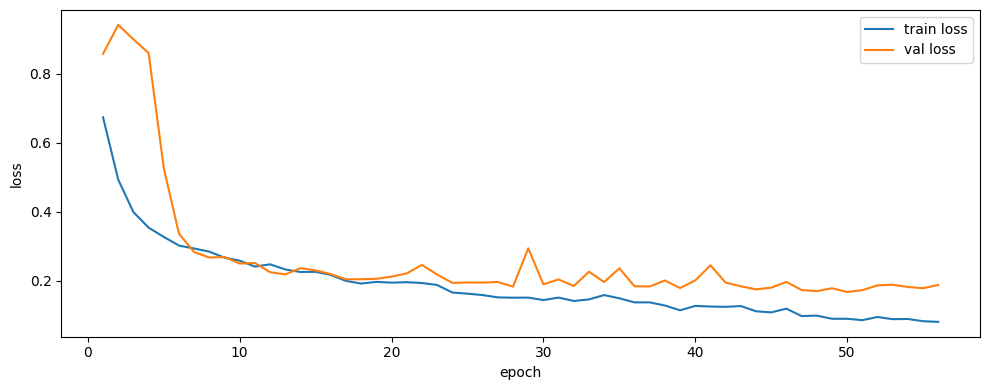

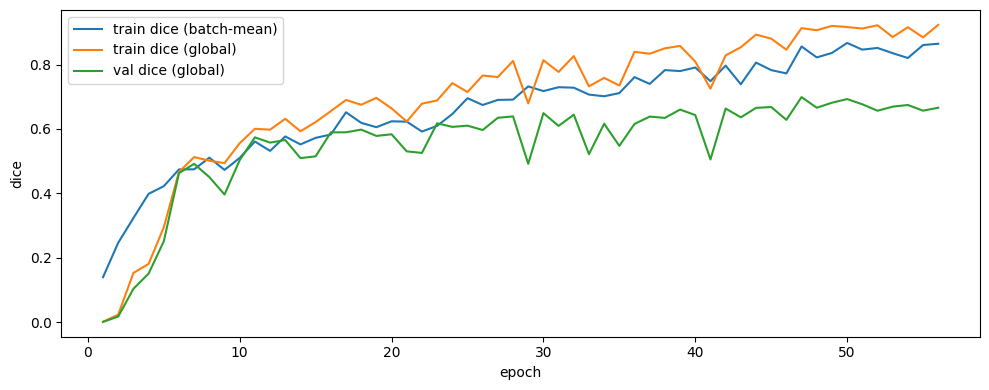

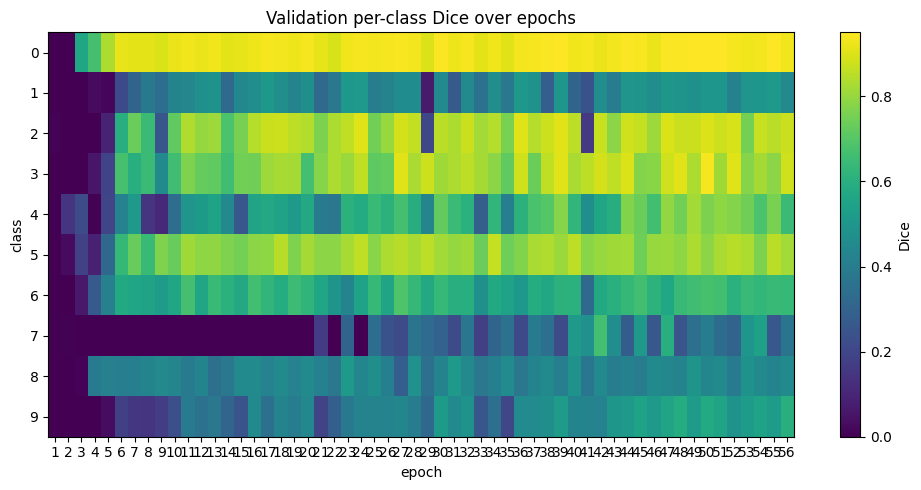

Val per-class Dice (latest): [0.931 0.448 0.875 0.882 0.648 0.819 0.635 0.37  0.452 0.599]
Early stopping: no improvement for 9 epochs.
Loaded best model from epoch 47 (val dice(global)=0.6989).

FINAL TEST | loss 0.2087 dice(global) 0.6802 | time 21s
Test per-class Dice: [0.925 0.545 0.815 0.854 0.824 0.97  0.71  0.    0.416 0.743]


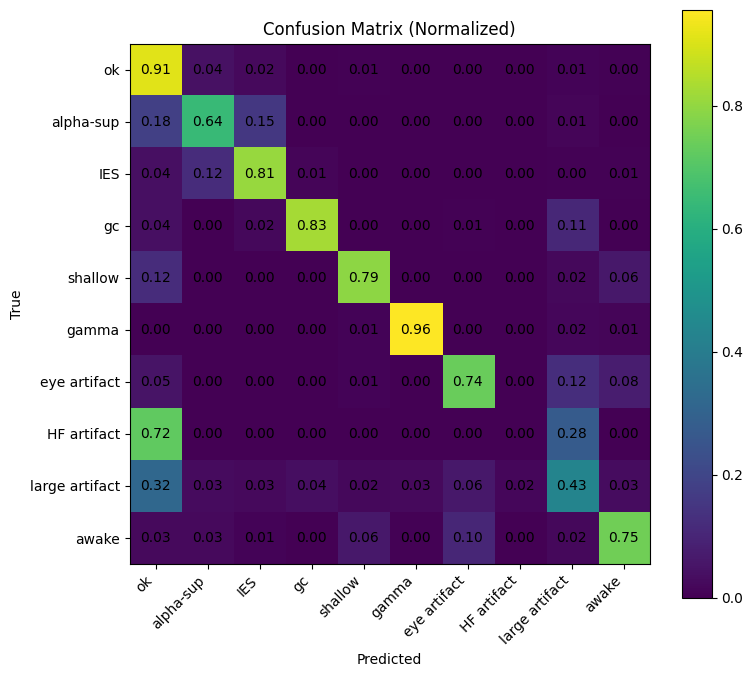

In [5]:

# -------------------------------------------------
# 2) Main training script (with progress, timing, ETA, live curves)
# Also compares train Dice (batch-mean) vs train Dice (global) each epoch.
# -------------------------------------------------
from IPython.display import clear_output

device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = 10
epochs = 100
patience = 9            # early stopping on VAL global dice
plot_every = 1          # update plots every N epochs

# X_spec: (N,45,297), Y: (N,297) numpy arrays
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
    X_spec, Y,
    test_size=0.2,
    val_size=0.2,
    random_state=42
)

# Log transform
X_train = np.log1p(X_train + 0.00000000001)
X_val   = np.log1p(X_val + 0.00000000001)
X_test  = np.log1p(X_test + 0.00000000001)

# Normalize using TRAIN statistics
mean = X_train.mean()
std = X_train.std() + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

print("Shapes:")
print("  Train:", X_train.shape, y_train.shape)
print("  Val:  ", X_val.shape, y_val.shape)
print("  Test: ", X_test.shape, y_test.shape)

# Build datasets/loaders
train_ds = SpectrogramSegDataset(X_train, y_train)
val_ds   = SpectrogramSegDataset(X_val, y_val)
test_ds  = SpectrogramSegDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

# Pick one model:
#model = BaselineSpecSeg(num_classes=num_classes).to(device)
model = ResAttnAnisoUNetTemporal(
    num_classes=num_classes,
    base=32,
    use_temporal_head=True,
    temporal_head="tcn",
    head_hidden=128,
    head_depth=3,
).to(device)
# model = ASTFeatureSeg(num_classes=num_classes).to(device)

# -------------------------------------------------
# 3) Class weights from TRAIN ONLY (log-inverse; stable for heavy imbalance)
# -------------------------------------------------
weights_np, counts_np = compute_log_inv_class_weights(y_train, num_classes=num_classes, c=1.02)
print("Train class counts:", counts_np)
print("Train class weights (log-inv):", weights_np)

class_weights = torch.tensor(weights_np, dtype=torch.float32).to(device)

# -------------------------------------------------
# 3b) Loss choice
# - start with focal+diceloss (recommended for imbalance)
# - or switch back to CE+Dice
# - or try hierarchical background-vs-nonbg then class
# -------------------------------------------------
USE_FOCAL = True
USE_HIERARCHICAL = True  # set True to use bg-vs-nonbg + multiclass loss

dice_weight = 0.3
focal_gamma = 2.0

if USE_HIERARCHICAL:
    loss_fn = HierarchicalBgThenClassLoss(
        num_classes=num_classes,
        dice_weight=dice_weight,
        gamma=focal_gamma,
        class_weights=class_weights,
        bg_weight=1.0
    )
elif USE_FOCAL:
    loss_fn = FocalDiceLoss(
        num_classes=num_classes,
        dice_weight=dice_weight,
        gamma=focal_gamma,
        class_weights=class_weights
    )
else:
    loss_fn = CEDiceLoss(
        num_classes=num_classes,
        dice_weight=dice_weight,
        class_weights=class_weights
    )
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

def format_seconds(s: float) -> str:
    s = int(round(s))
    h = s // 3600
    m = (s % 3600) // 60
    sec = s % 60
    if h > 0:
        return f"{h}h {m:02d}m {sec:02d}s"
    if m > 0:
        return f"{m}m {sec:02d}s"
    return f"{sec}s"

def plot_history(hist):
    epochs_axis = np.arange(1, len(hist["train_loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_axis, hist["train_loss"], label="train loss")
    plt.plot(epochs_axis, hist["val_loss"], label="val loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs_axis, hist["train_dice_batch"], label="train dice (batch-mean)")
    plt.plot(epochs_axis, hist["train_dice_global"], label="train dice (global)")
    plt.plot(epochs_axis, hist["val_dice_global"], label="val dice (global)")
    plt.xlabel("epoch"); plt.ylabel("dice"); plt.legend(); plt.tight_layout()
    plt.show()


    # Val per-class Dice heatmap (rows=classes, cols=epochs)
    if len(hist.get("val_dice_per_class", [])) > 0:
        mat = np.stack(hist["val_dice_per_class"], axis=1)  # (C, E)
        plt.figure(figsize=(10, 5))
        plt.imshow(mat, aspect="auto")
        plt.colorbar(label="Dice")
        plt.xlabel("epoch")
        plt.ylabel("class")
        plt.title("Validation per-class Dice over epochs")
        plt.yticks(np.arange(mat.shape[0]))
        plt.xticks(np.arange(mat.shape[1]), np.arange(1, mat.shape[1] + 1))
        plt.tight_layout()
        plt.show()
# -------------------------------------------------
# 4) Train using VAL GLOBAL Dice for model selection
#    and compute TRAIN GLOBAL Dice at epoch end for comparison
# -------------------------------------------------
history = {
    "train_loss": [],
    "train_dice_batch": [],
    "train_dice_global": [],
    "val_loss": [],
    "val_dice_global": [],
    "val_dice_per_class": [],
    "train_dice_per_class": [],
    "epoch_time": [],
}

best_val = -1.0
best_state = None
best_epoch = -1
no_improve = 0

for epoch in range(1, epochs + 1):
    # Train epoch (shows tqdm progress); returns batch-mean dice + elapsed
    tr_loss, tr_dice_batch, tr_time = run_one_epoch(
        model, train_loader, optimizer, loss_fn, device, num_classes, train=True, desc=f"train {epoch}/{epochs}"
    )

    # Compute TRAIN global dice at epoch end (for comparison)
    tr_loss_eval, tr_dice_global, tr_dice_per_class, tr_eval_time = eval_epoch_global(
        model, train_loader, loss_fn, device, num_classes
    )

    # Validate with GLOBAL dice
    va_loss, va_dice_global, va_dice_per_class, va_time = eval_epoch_global(
        model, val_loader, loss_fn, device, num_classes
    )

    epoch_time = tr_time + tr_eval_time + va_time

    history["train_loss"].append(tr_loss)
    history["train_dice_batch"].append(tr_dice_batch)
    history["train_dice_global"].append(tr_dice_global)
    history["train_dice_per_class"].append(tr_dice_per_class)
    history["val_loss"].append(va_loss)
    history["val_dice_global"].append(va_dice_global)
    history["val_dice_per_class"].append(va_dice_per_class)
    history["epoch_time"].append(epoch_time)

    # Save best checkpoint by validation GLOBAL Dice
    if va_dice_global > best_val:
        best_val = va_dice_global
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    # ETA
    avg_epoch_time = float(np.mean(history["epoch_time"]))
    remaining = epochs - epoch
    eta = remaining * avg_epoch_time

    # Display
    if epoch % plot_every == 0:
        clear_output(wait=True)
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {tr_loss:.4f} | "
            f"train dice batch {tr_dice_batch:.4f} vs global {tr_dice_global:.4f} | "
            f"val loss {va_loss:.4f} val dice(global) {va_dice_global:.4f} | "
            f"epoch time {format_seconds(epoch_time)} | ETA {format_seconds(eta)}"
        )
        print(f"Best val dice(global): {best_val:.4f} (epoch {best_epoch}) | no-improve {no_improve}/{patience}")
        plot_history(history)
        print("Val per-class Dice (latest):", np.round(va_dice_per_class, 3))

    if no_improve >= patience:
        print(f"Early stopping: no improvement for {patience} epochs.")
        break

# Load best model (by val GLOBAL dice)
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)
    print(f"Loaded best model from epoch {best_epoch} (val dice(global)={best_val:.4f}).")

# -------------------------------------------------
# 5) Final evaluation ONCE on TEST (GLOBAL dice)
# -------------------------------------------------
te_loss, te_dice_global, te_dice_per_class, te_time = eval_epoch_global(
    model, test_loader, loss_fn, device, num_classes
)
print(f"\nFINAL TEST | loss {te_loss:.4f} dice(global) {te_dice_global:.4f} | time {format_seconds(te_time)}")
print("Test per-class Dice:", np.round(te_dice_per_class, 3))

# Plot confusion matrix
cm = compute_confusion_matrix(model, test_loader, device, num_classes)
classes = ["ok", "alpha-sup", "IES", "gc", "shallow", "gamma", "eye artifact", "HF artifact", "large artifact", 'awake']
plot_confusion_matrix(cm, class_names= classes, normalize=True)


# NOTE: see for saving model and transform 

# Visualise ouput of model

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


classes = ["ok", "alpha-sup", "IES", "gc", "shallow",
           "gamma", "eye artifact", "HF artifact",
           "large artifact", "awake"]

def annotate_mask(mask, class_names, title="Mask"):
    T = len(mask)

    plt.figure(figsize=(14, 2))
    plt.imshow(mask[None, :], aspect="auto")
    plt.yticks([])
    plt.title(title)

    # Find segment boundaries
    changes = np.where(mask[1:] != mask[:-1])[0] + 1
    segments = np.split(np.arange(T), changes)

    for seg in segments:
        start = seg[0]
        end = seg[-1]
        mid = (start + end) // 2
        label = class_names[mask[start]]
        plt.text(mid, 0, label,
                 ha="center", va="center",
                 fontsize=8, rotation=45)

    plt.tight_layout()
    plt.show()


def plot_spec_with_mask(x_log, mask, class_names, title):
    T = mask.shape[0]

    plt.figure(figsize=(14, 4))
    plt.imshow(x_log, aspect="auto", origin="lower")

    # Color bar for mask (transparent overlay)
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(len(class_names))]

    for t in range(T):
        plt.axvspan(t, t+1, color=colors[mask[t]], alpha=0.08)

    # Legend
    patches = [mpatches.Patch(color=colors[i], label=class_names[i])
               for i in range(len(class_names))]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(title)
    plt.xlabel("Time frame")
    plt.ylabel("Freq bin")
    plt.tight_layout()
    plt.show()


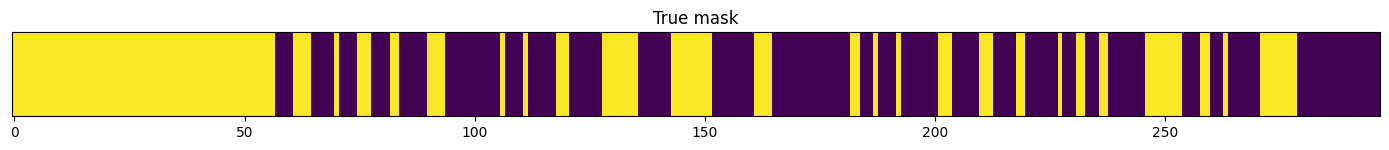

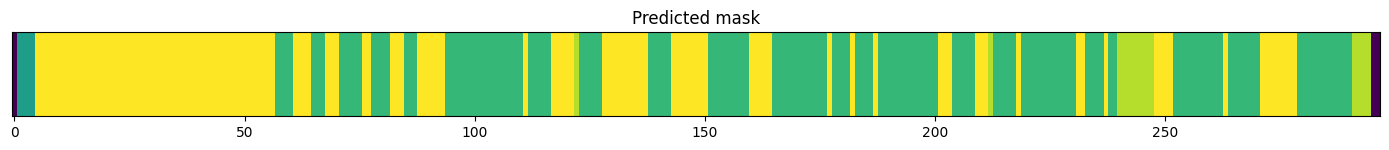

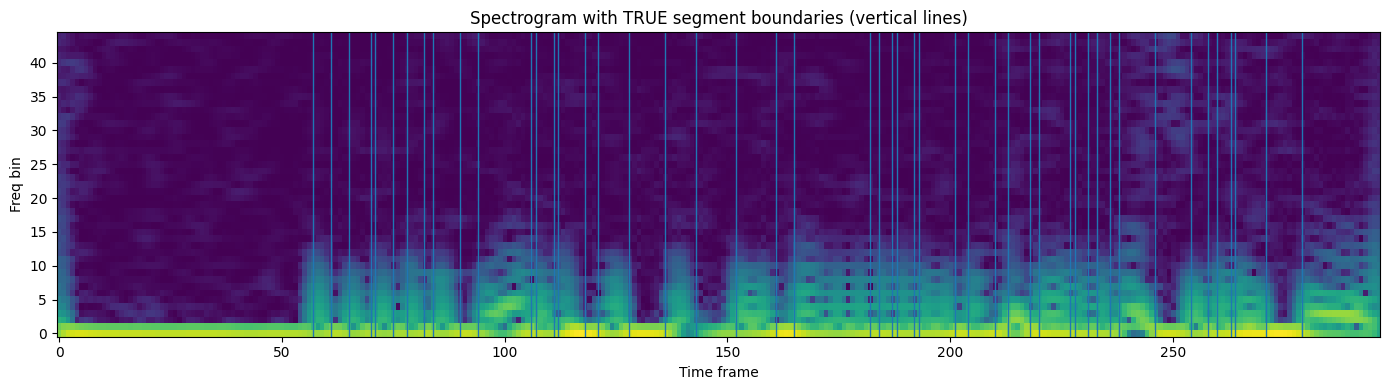

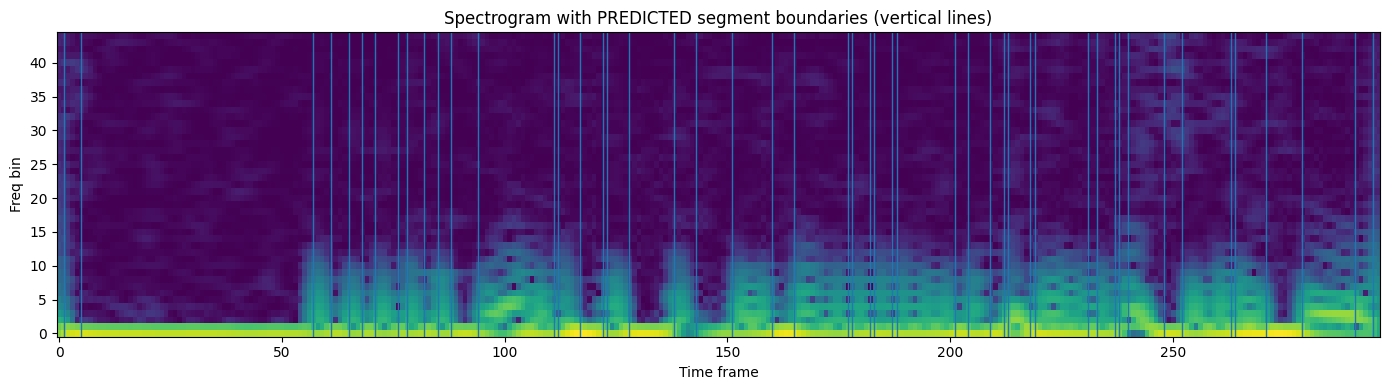

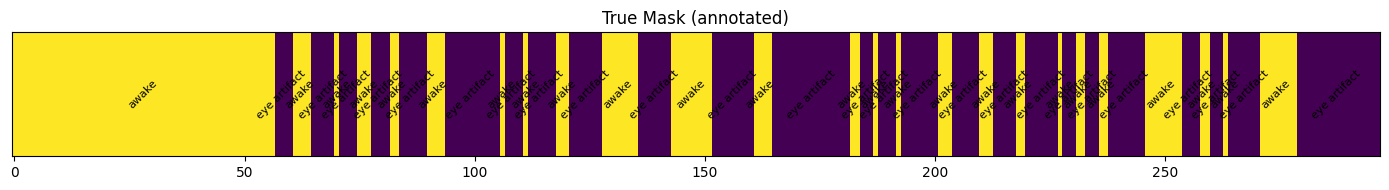

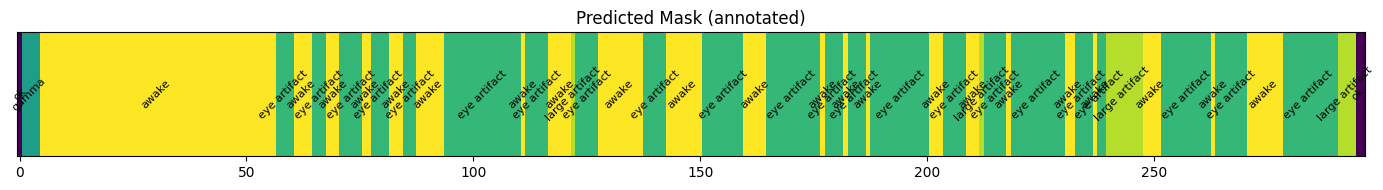

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

idx = 15

# Already preprocessed spectrogram (log1p + global z-norm)
x_norm = X_test[idx].astype(np.float32)   # (45,297)
y_true = y_test[idx]                      # (297,)

# Forward
x_t = torch.from_numpy(x_norm).unsqueeze(0).to(device)
with torch.no_grad():
    logits = model(x_t)                    # (1,297,C)
    probs = torch.softmax(logits, dim=-1)
    y_pred = logits.argmax(dim=-1).squeeze(0).cpu().numpy()

# Optional: recover "log1p scale" spectrogram for nicer visuals
# because: x_norm = (x_log - mean) / std  =>  x_log = x_norm*std + mean
x_log = x_norm * std + mean   # requires mean/std variables from your training cell


# ---------- Masks as stripes ----------
plt.figure(figsize=(14, 1.6))
plt.imshow(y_true[None, :], aspect="auto")
plt.yticks([])
plt.title("True mask")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 1.6))
plt.imshow(y_pred[None, :], aspect="auto")
plt.yticks([])
plt.title("Predicted mask")
plt.tight_layout()
plt.show()

# ---------- Overlay mask boundaries on spectrogram ----------
def segment_boundaries(mask_1d: np.ndarray):
    # indices where label changes
    return np.where(mask_1d[1:] != mask_1d[:-1])[0] + 1

true_bounds = segment_boundaries(y_true)
pred_bounds = segment_boundaries(y_pred)

plt.figure(figsize=(14, 4))
plt.imshow(x_log, aspect="auto", origin="lower")
for t in true_bounds:
    plt.axvline(t, linewidth=1)  # true boundaries
plt.title("Spectrogram with TRUE segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.imshow(x_log, aspect="auto", origin="lower")
for t in pred_bounds:
    plt.axvline(t, linewidth=1)  # predicted boundaries
plt.title("Spectrogram with PREDICTED segment boundaries (vertical lines)")
plt.xlabel("Time frame")
plt.ylabel("Freq bin")
plt.tight_layout()
plt.show()


annotate_mask(y_true, classes, title="True Mask (annotated)")
annotate_mask(y_pred, classes, title="Predicted Mask (annotated)")
